In [5]:
!pip install -q langchain langchain_core langchain_experimental langchain_text_splitters langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.1/500.1 kB 7.6 MB/s eta 0:00:00


In [6]:
import dotenv
import os
dotenv.load_dotenv("/content/.env")

True

In [7]:
import os
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base=os.getenv("OPENROUTER_BASE_URL"),
    model_name="gpt-4o-mini-2024-07-18", # Or any model on OpenRouter
    default_headers={
        "HTTP-Referer": os.getenv("APP_URL"),
        "X-Title": os.getenv("APP_NAME"),
    }
)

In [8]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(
    openai_api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base=os.getenv("OPENROUTER_BASE_URL"),
    model="text-embedding-3-small", # Or any model on OpenRouter
    default_headers={
        "HTTP-Referer": os.getenv("APP_URL"),
        "X-Title": os.getenv("APP_NAME"),
    })

In [10]:
!pip install -q faiss-cpu langchain_community

## Parent Document Retervial

In [13]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# loaded the document
loader = TextLoader('/content/kb_modiji.txt')
documents = loader.load()

# initiated the parent and the child splitter
# parent will have higer chunk size compared to chil splitter
parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000)

child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100, chunk_overlap = 10)

In [17]:
# this is a hack to find out what should be the column size
# of the empty vector matrix
# since the embedding model may change, we can't hard code this.
sample_embedding = embeddings.embed_query("hello how are you")
embedding_dim = len(sample_embedding)

In [19]:
# let's now create the empty embedding vector matrix
import faiss
index = faiss.IndexFlatL2(embedding_dim)

<faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x7a1a3f87d1a0> >

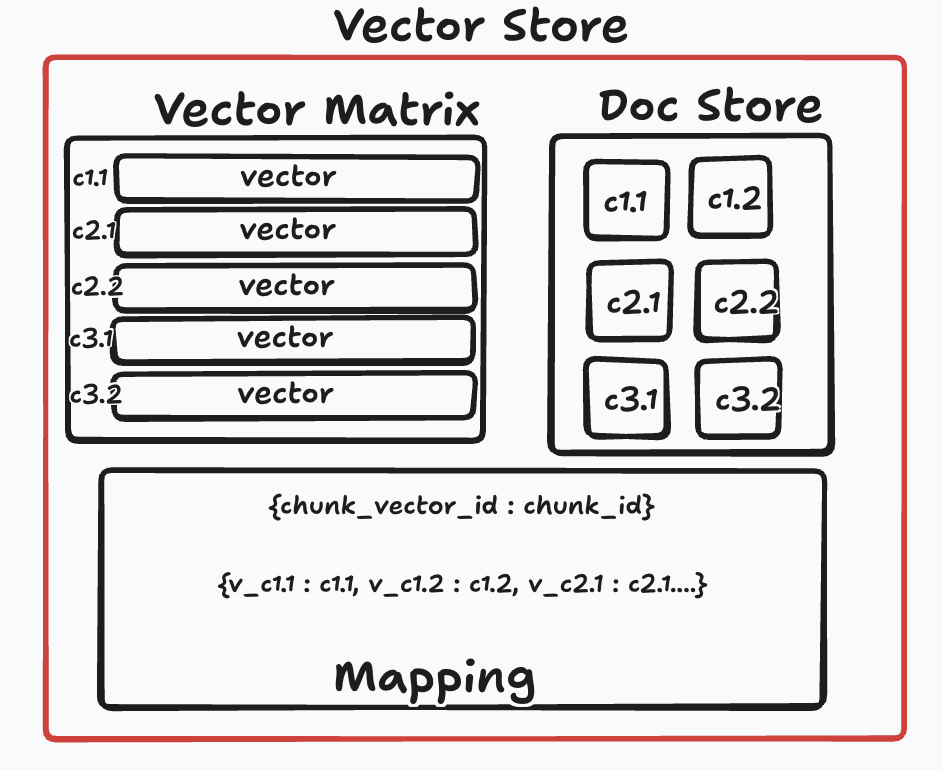

In [30]:
# langchain vector store
# location to preserve the sentence embedding
# with the chunks and their mapping
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore
vectorstore = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)

In [31]:
# location in RAM to preseve bigger chunk
from langchain_core.stores import InMemoryStore
store = InMemoryStore()

In [32]:
from langchain_classic.retrievers import ParentDocumentRetriever
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore = store,
    child_splitter = child_splitter,
    parent_splitter = parent_splitter)

In [33]:
retriever.add_documents(documents, ids = None)

In [34]:
retriever.invoke("Public schems and government initiatives")

[Document(metadata={'source': '/content/kb_modiji.txt'}, page_content='**Second Term (2019-2024):**\n- Won re-election with increased majority (303 seats)\n- Sworn in on May 30, 2019\n\n*Major Developments:*\n- Abrogation of Article 370 (special status of Jammu and Kashmir) in August 2019\n- Citizenship Amendment Act (2019)\n- COVID-19 pandemic management (2020-2022)\n- Vaccine development and distribution (Covaxin, Covishield)\n- Ayushman Bharat health insurance scheme expansion\n- Housing for All initiatives\n- Infrastructure development focus\n\n**Third Term (2024-Present):**\n- Won 2024 general elections\n- BJP did not secure absolute majority on its own but formed government with NDA alliance\n- Currently serving as Prime Minister\n\n## Key Policies and Programs\n\n**Economic Initiatives:**\n- Production Linked Incentive (PLI) Scheme\n- Atmanirbhar Bharat (Self-Reliant India)\n- Startup India\n- Mudra Yojana for small businesses\n- National Infrastructure Pipeline\n\n**Social Welf

**Chunk Compression**

In [35]:
!pip install -q llmlingua accelerate

In [37]:
from llmlingua import PromptCompressor
llm_lingua = PromptCompressor(
    model_name = "microsoft/llmlingua-2-bert-base-multilingual-cased-meetingbank",
    use_llmlingua2=True,
    device_map="cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [38]:
def retriever_compressor(query):
  docs = retriever.invoke(query)

  if not docs:
    return "No Relevant Document Fetched"

  context = "\n\n".join([doc.page_content for doc in docs])

  compress_context = llm_lingua.compress_prompt(
      context,
      rate = 0.7,
      target_token = 500
  )

  return compress_context['compressed_prompt']

In [39]:
retriever_compressor("Public schems and government initiatives")

'* * Second Term ( 2019 - 2024 ) : * * - Won re - election with increased majority ( 303 seats ) - Sworn in on May 30, 2019 * Major Developments : * - Abrogation of Article 370 ( special status of Jammu and Kashmir ) in August 2019 - Citizenship Amendment Act ( 2019 ) - COVID - 19 pandemic management ( 2020 - 2022 ) - Vaccine development and distribution ( Covaxin, Covishield ) - Ayushman Bharat health insurance scheme expansion - Housing for All initiatives - Infrastructure development focus * * Third Term ( 2024 - Present ) : * * - Won 2024 general elections - BJP did not secure absolute majority on its own but formed government with NDA alliance - Currently serving as Prime Minister # # Key Policies and Programs * * Economic Initiatives : * * - Production Linked Incentive ( PLI ) Scheme - Atmanirbhar Bharat ( Self - Reliant India ) - Startup India - Mudra Yojana for small businesses - National Infrastructure Pipeline * * Social Welfare : * * - Beti Bachao Beti Padhao ( Save and Educ

In [42]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

template = """You MUST answer ONLY using the context below.
If the answer is not present, reply exactly:
"I don't know based on the provided context."

Context:
{context}

Question: {question}

Answer:"""

prompt = ChatPromptTemplate.from_template(template)

rag_chain = (
    {
        "context":retriever_compressor,
        "question":RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

q = input("Enter a question: ")
response = rag_chain.invoke(q)
print(response)

Enter a question: What are public schemes and government initiatives by narendra modi
Swachh Bharat Abhiyan (Clean India Mission), Make in India campaign, Digital India initiative, Jan Dhan Yojana (financial inclusion), Skill India program, Pradhan Mantri Ujjwala Yojana (LPG), Goods and Services Tax (GST) implementation, Production Linked Incentive (PLI) Scheme, Atmanirbhar Bharat (Self-Reliant), Startup India, Mudra Yojana (small businesses), Beti Bachao Beti Padhao (Save Educate Girl Child), KISAN (direct income support), Ayushman Bharat (health insurance), Housing for All initiatives, rural development programs, technology innovation, digital payments (UPI expansion), Aadhaar service delivery, Smart Cities Mission, and advancements in the space program.


In [45]:
sum([len(i.page_content) for i in retriever.invoke(" What are public schemes and government initiatives by narendra modi")])

3745

In [46]:
len(retriever_compressor(" What are public schemes and government initiatives by narendra modi"))

2651

## Knowledge Graphs

In [47]:
!pip install -q langchain_experimental langchain_neo4j neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.2/222.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.6/330.6 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.


In [48]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# loaded the document
loader = TextLoader('/content/kb_modiji.txt')
documents = loader.load()


In [52]:
NEO4J_URI="neo4j+s://a9bca325.databases.neo4j.io"
NEO4J_USERNAME="neo4j"
NEO4J_PASSWORD="qNOymRNvKVv3KxAi1wCryskpuNzH2W0yPJLJ-KNwGZ8"

In [53]:
from langchain_neo4j import Neo4jGraph
graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD
)

In [54]:
from langchain_experimental.graph_transformers import LLMGraphTransformer
llm_transformer = LLMGraphTransformer(llm = llm)

In [55]:
graph_docs = llm_transformer.convert_to_graph_documents(documents)

In [56]:
graph.add_graph_documents(graph_docs)

**Summary**

- Parent Document Reterival
- Implemented it with Code.
- In Memory Doc and How to initiate the vector Store with chunks
- Graph Data Base
- When to use Knowledge Graphs over regular chunking
- Used LLM to generate nodes, entities and relationship
- connected neo4j with the server
- We add the text(document) to the server as node entities and relationship
